<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Matter002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

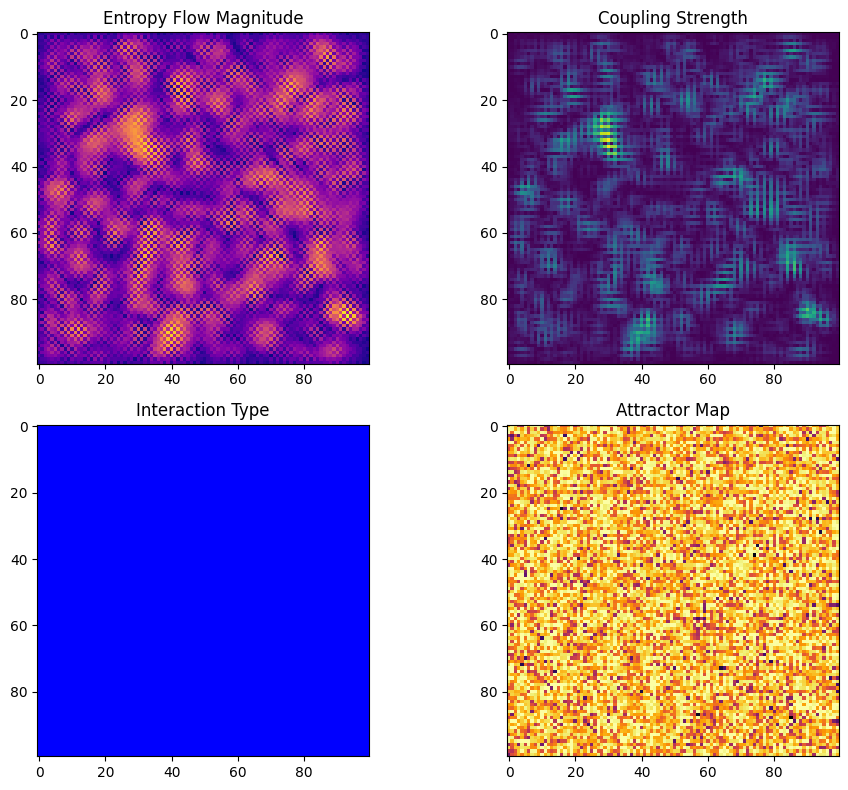

In [2]:
# 🧪 Matter002: Force Encoding – HES Lattice Simulation

import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
N = 100  # Lattice size
steps = 500  # Evolution steps
entropy_seed_strength = 0.1
curvature_threshold = 0.05

# --- Initialize Entropic Lattice ---
S = np.random.rand(N, N) * entropy_seed_strength
curvature_memory = np.zeros_like(S)
attractor_map = np.zeros_like(S)

# --- Evolution Function ---
def evolve(S):
    grad_x, grad_y = np.gradient(S)
    laplacian = np.gradient(grad_x)[0] + np.gradient(grad_y)[1]
    S_new = S - 0.01 * laplacian
    return S_new

# --- Simulation Loop ---
for t in range(steps):
    S = evolve(S)
    curvature = np.abs(np.gradient(np.gradient(S)[0])[0] + np.gradient(np.gradient(S)[1])[1])
    curvature_memory += curvature
    attractor_map += (curvature > curvature_threshold).astype(float)

# --- Entropy Flow Vectors ---
grad_x, grad_y = np.gradient(S)
entropy_flow_magnitude = np.sqrt(grad_x**2 + grad_y**2)
entropy_flow_direction = np.arctan2(grad_y, grad_x)

# --- Coupling Strength ---
coupling_strength = entropy_flow_magnitude * curvature_memory

# --- Interaction Type Classification ---
interaction_type = np.zeros_like(S)
interaction_type[coupling_strength > 0.5] = 1  # Attractive
interaction_type[(coupling_strength > 0.2) & (coupling_strength <= 0.5)] = -1  # Repulsive
# Neutral remains 0

# --- Visualization ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(entropy_flow_magnitude, cmap='plasma'); axs[0, 0].set_title("Entropy Flow Magnitude")
axs[0, 1].imshow(coupling_strength, cmap='viridis'); axs[0, 1].set_title("Coupling Strength")
axs[1, 0].imshow(interaction_type, cmap='bwr'); axs[1, 0].set_title("Interaction Type")
axs[1, 1].imshow(attractor_map, cmap='inferno'); axs[1, 1].set_title("Attractor Map")
plt.tight_layout(); plt.show()
